In [1]:
import jampy as jam
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
from astropy.table import Table
from mgefit.mge_fit_sectors import mge_fit_sectors
from mgefit.mge_fit_sectors_regularized import mge_fit_sectors_regularized
from mgefit.find_galaxy import find_galaxy
from mgefit.sectors_photometry import sectors_photometry
from mgefit.mge_print_contours import mge_print_contours
import astropy.io.fits as fits

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals/')

from IO_data import extract_Pipe3d_data, extract_data

 
jam.axi.proj(align='cyl', moment='zz') -- elapsed time sec: 0.35
analytic_los=1 logistic=0 constant_anisotropy=1
inc=90.0; beta[0]=0.0; kappa=1.00; M/L=0.736; BH=7.4e+07; chi2/DOF=0.828
Total mass MGE (MSun): 7.237e+10



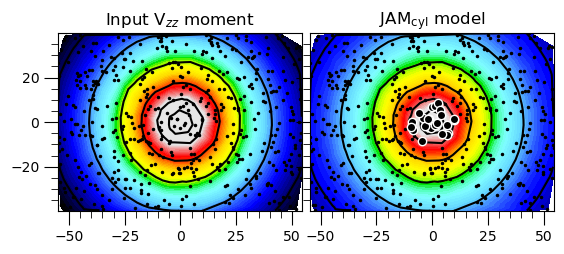

AttributeError: 'float' object has no attribute 'size'

<Figure size 640x480 with 0 Axes>

In [9]:
rng = np.random.default_rng(123)
xbin, ybin = rng.uniform(low=[-55, -40], high=[55, 40], size=[500, 2]).T

inc = 90.                                                # Assumed galaxy inclination
r = np.sqrt(xbin**2 + (ybin)**2) # Radius in the plane of the disk
a = 40                                                   # Scale length in arcsec
# vr = 2000*np.sqrt(r)/(r + a)                             # Assumed velocity profile (v_c of Hernquist 1990)
# vel = vr * np.sin(np.radians(inc))*xbin/r                # Projected velocity field
vel=0.
sig = 8700/(r + a)                                       # Assumed velocity dispersion profile
rms = np.sqrt(vel**2 + sig**2)                           # Vrms field in km/s

# Until here I computed some fake input kinematics to fit with JAM.
# Ina real application, instead of the above lines one will read the measured
# stellar kinematics `vel` and `sig`, e.g. from integral-field spectroscopy

surf = np.array([39483., 37158., 30646., 17759., 5955.1, 1203.5, 174.36, 21.105, 2.3599, 0.25493])
sigma = np.array([0.153, 0.515, 1.58, 4.22, 10, 22.4, 48.8, 105, 227, 525])
qobs = np.full_like(sigma, 1)

distance = 16.5     # Assume Virgo distance in Mpc (Mei et al. 2007)
mbh = 1e8           # Black hole mass in solar masses
beta = np.full_like(surf, 0.2)

# As alternative to setting the anisotropy of each individual Gaussian, one
# can specify an analytic radial variation for the anisotropy, of the form
#
#   beta(r) = beta_0 + (beta_inf - beta_0)/[1 + (r_a/r)^alpha]    # with align='sph'
#   beta(z) = beta_0 + (beta_inf - beta_0)/[1 + (z_a/|z|)^alpha]  # with align='cyl'
#
# by specifying beta as a list of 4-element as follows (see documentation):
#
# r_a = 15        # Anisotropy transition radius in arcsec
# beta_0 = 0.2    # Inner anisotropy
# beta_inf = 0.4  # Outer anisotropy
# alpha = 1       # Sharpness of the anisotropy transition
# beta = [r_a, beta_0, beta_inf, alpha]

# Below I assume mass follows light, but in a real application one
# will generally include a dark halo in surf_pot, sigma_pot, qobs_pot.
# See jam_dark_halo_bayes_example.py and e.g. Cappellari (2013) for an example
# https://ui.adsabs.harvard.edu/abs/2013MNRAS.432.1709C

surf_lum = surf_pot = surf
sigma_lum = sigma_pot = sigma
qobs_lum = qobs_pot = qobs

sigmapsf = [0.6, 1.2]
normpsf = [0.7, 0.3]
pixsize = 0.8
goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins

# I use a loop below, just to highlight the fact that all parameters
# remain the same for the two JAM calls, except for 'moment' and 'data'
plt.figure(1)
for moment, data in zip(['zz', 'z'], [rms, vel]):

    print(" ")
    # The model is by design similar but not identical to the adopted kinematics!
    out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                       inc, mbh, distance, xbin, ybin, plot=True, data=data,
                       sigmapsf=sigmapsf, normpsf=normpsf, beta=None, pixsize=pixsize,
                       moment=moment, goodbins=goodbins, align='cyl', ml=None)
    plt.pause(3)
    plt.figure(2)
    surf_pot *= out.ml  # Scale the density by the best fitting M/L from the previous step

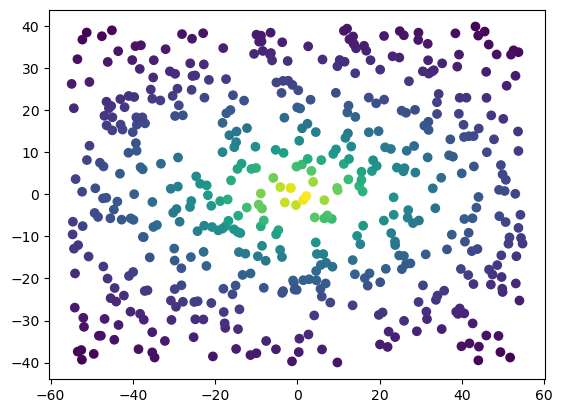

In [5]:
plt.scatter(xbin,ybin, c=sig)

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'
master_table_fn = DATA_FOLDER + 'output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_v2.fits'

In [5]:
master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [6]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [7]:
test_gal = '8319-1902'
idx = master_table_dict[test_gal]
sMass_maps = extract_Pipe3d_data(PIPE3D_FOLDER, test_gal, ['sMass', 'star_sigma'])
vel_maps = extract_data(VEL_FOLDER, test_gal, ['flux', 'Ha', 'star_sigma'])
PA = master_table[idx]['nsa_elpetro_phi']
ba = master_table[idx]['nsa_elpetro_ba']

In [8]:
L = np.array([26.106, 19.858, 144.43])
sigma = np.array([1.822, 4.221, 4.473])
q = np.array([1.0000, 0.4493, 1.0000])

In [9]:
#need to rotate vel map and sigma map so they line up w x/y axes
center = (17, 17)
im_axis = np.linspace(0, 33, 33 +1)
dist_x, dist_y = im_axis - 17, im_axis-17
xs, ys = np.meshgrid(dist_x, dist_y)

rot_xs = xs*np.cos(np.radians(54.4)) - ys*np.sin(np.radians(54.4))
rot_ys = xs*np.sin(np.radians(54.4)) + ys*np.cos(np.radians(54.4))

In [10]:
np.shape(vel_maps['star_sigma'])

(34, 34)

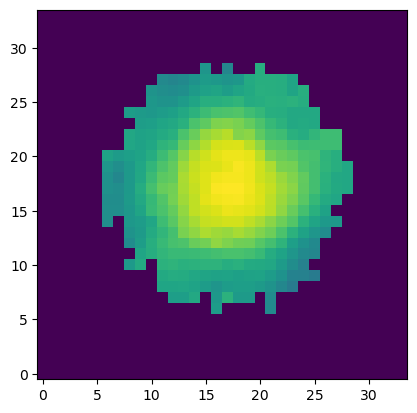

In [11]:
plt.imshow(vel_maps['star_sigma'])
plt.gca().invert_yaxis()

In [12]:
inc = np.degrees(np.arccos(np.sqrt((ba**2 - 0.2**2)/(1-0.2**2))))

In [13]:
np.where(xbin[:595:]==0)

(array([], dtype=int64),)

In [14]:
np.where(ybin==0)

(array([], dtype=int64),)

In [15]:
[0,1,2,3][2:]

[2, 3]

In [16]:
inc = np.degrees(np.arccos(np.sqrt((0.05**2-0.2**2)/(1-0.2**2))))
inc

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_49019/777228684.py:1: RuntimeWarning: invalid value encountered in sqrt
  inc = np.degrees(np.arccos(np.sqrt((0.05**2-0.2**2)/(1-0.2**2))))


nan

In [17]:
if not np.isfinite(rms).all():
    print('AHHHHHH')

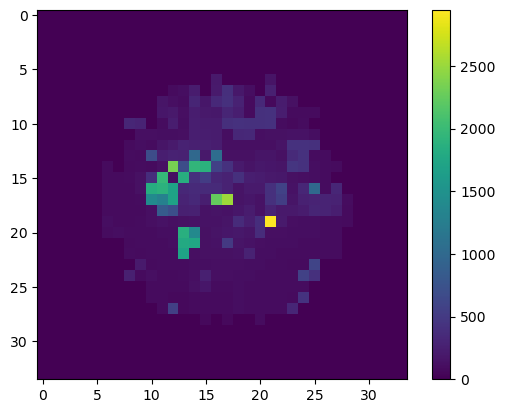

In [18]:
plt.imshow(np.sqrt(vel_maps['Ha_vel']**2 + vel_maps['star_sigma']**2))
plt.colorbar()

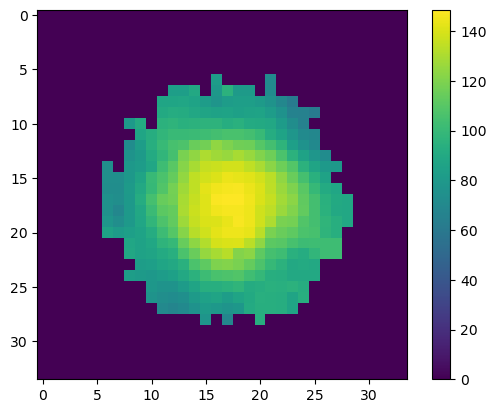

In [19]:
plt.imshow(vel_maps['star_sigma'])
plt.colorbar()

jam.axi.proj(align='cyl', moment='zz') -- elapsed time sec: 0.05
analytic_los=1 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.0; kappa=1.00; M/L=8.96e+03; BH=0.0; chi2/DOF=6.53
Total mass MGE (MSun): 1.092e+10



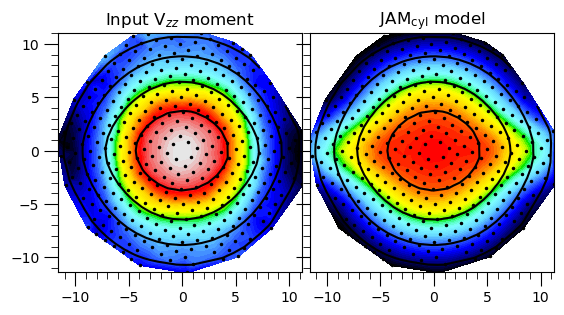

<Figure size 640x480 with 0 Axes>

In [20]:



# inc = 0.                                                # Assumed galaxy inclination
# r = np.sqrt(xbin**2 + (ybin/np.cos(np.radians(inc)))**2) # Radius in the plane of the disk
# a = 40                                                   # Scale length in arcsec
# vr = 2000*np.sqrt(r)/(r + a)                             # Assumed velocity profile (v_c of Hernquist 1990)
# vel = vr * np.sin(np.radians(inc))*xbin/r                # Projected velocity field
# sig = 8700/(r + a)                                       # Assumed velocity dispersion profile

inc = 90
# vel = np.concatenate((vel_maps['Ha_vel'].flatten()[:595], vel_maps['Ha_vel'].flatten()[596:]))
vel = np.zeros(1155)
sig = np.concatenate((vel_maps['star_sigma'].flatten()[:595], vel_maps['star_sigma'].flatten()[596:]))
rms = np.sqrt(vel**2 + sig**2)                           # Vrms field in km/s
# rms=sig

xbin = np.concatenate((rot_xs.flatten()[:595], rot_xs.flatten()[596:]))[rms>0]
ybin = np.concatenate((rot_ys.flatten()[:595], rot_ys.flatten()[596:]))[rms>0]
rms = rms[rms>0]

# Until here I computed some fake input kinematics to fit with JAM.
# Ina real application, instead of the above lines one will read the measured
# stellar kinematics `vel` and `sig`, e.g. from integral-field spectroscopy

surf = np.array(L / (2*np.pi*q*sigma**2))
sigma = np.array(sigma)
qobs = np.array(q)

distance = 16.5     # Assume Virgo distance in Mpc (Mei et al. 2007)
mbh = 0         # Black hole mass in solar masses
# beta = np.full_like(surf, 0.2)

# As alternative to setting the anisotropy of each individual Gaussian, one
# can specify an analytic radial variation for the anisotropy, of the form
#
#   beta(r) = beta_0 + (beta_inf - beta_0)/[1 + (r_a/r)^alpha]    # with align='sph'
# beta(z) = beta_0 + (beta_inf - beta_0)/[1 + (z_a/|z|)^alpha]  # with align='cyl'
#
# by specifying beta as a list of 4-element as follows (see documentation):
#
# r_a = 15        # Anisotropy transition radius in arcsec
# beta_0 = 0.2    # Inner anisotropy
# beta_inf = 0.4  # Outer anisotropy
# alpha = 1       # Sharpness of the anisotropy transition
# beta = [r_a, beta_0, beta_inf, alpha]

# Below I assume mass follows light, but in a real application one
# will generally include a dark halo in surf_pot, sigma_pot, qobs_pot.
# See jam_dark_halo_bayes_example.py and e.g. Cappellari (2013) for an example
# https://ui.adsabs.harvard.edu/abs/2013MNRAS.432.1709C

surf_lum = surf_pot = surf
sigma_lum = sigma_pot = sigma
qobs_lum = qobs_pot = qobs

sigmapsf = 0
normpsf = 1
pixsize = 1
# goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins


plt.figure(1)
out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                       inc, mbh, 
                   distance, 
                   xbin, ybin, plot=True, data=rms,
                       #sigmapsf=sigmapsf, normpsf=normpsf, 
                       #beta=beta, 
                       pixsize=pixsize,
                       moment='zz',
                       #goodbins=goodbins,
                       align='cyl', ml=None,
                      pixang=54.4,
                  #logistic=True,
                  )
plt.pause(3)
plt.figure(2)
surf_pot *= out.ml  # Scale the density by the best fitting M/L from the previous step

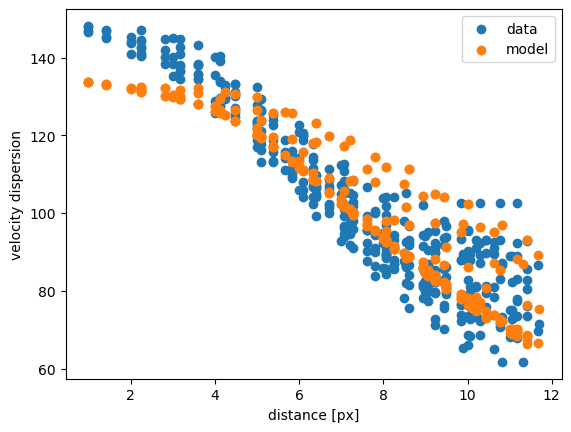

In [23]:
dist = np.sqrt(xbin**2 + ybin**2)
plt.scatter(dist, rms, label='data')
plt.scatter(dist, out.model, label='model')
plt.xlabel('distance [px]')
plt.ylabel('velocity dispersion')
plt.legend()

In [149]:
np.log10(1.092E10)

10.038222638368719

In [160]:
L*out.ml

array([ 233951.4449134 ,  177959.38838161, 1294323.41947608])

In [152]:
out.ml

8961.596756048453

In [154]:
L

array([ 26.106,  19.858, 144.43 ])

In [155]:
surf

array([11216.28712295,  3538.13103671, 10295.91965031])

(array([ 4., 10., 46., 92., 89., 66., 29., 23., 18.,  6.]),
 array([-32.53483595, -25.59845669, -18.66207743, -11.72569817,
         -4.78931891,   2.14706035,   9.0834396 ,  16.01981886,
         22.95619812,  29.89257738,  36.82895664]),
 <BarContainer object of 10 artists>)

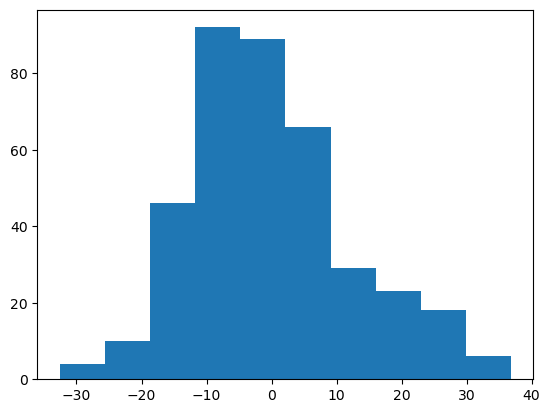

In [146]:
plt.hist(out.model-rms)

In [163]:
2*np.pi*surf_pot*qobs_lum*sigma_lum**2

array([ 233951.4449134 ,  177959.38838161, 1294323.41947608])

In [ ]:
# Axisymmetric deprojection of both luminous and total mass.
    # See equation (12)-(14) of Cappellari (2008)
    inc = np.radians(inc_deg)
    qmin = 0.05   # Minimum desired intrinsic axial ratio
    qobsmin = np.sqrt(np.cos(inc)**2 + (qmin*np.sin(inc))**2)

    assert np.all(qobs_lum >= qobsmin), f'Inclination too low q_lum < {qmin}'
    qintr_lum = np.sqrt(qobs_lum**2 - np.cos(inc)**2)/np.sin(inc)
    dens_lum = surf_lum*qobs_lum/(sigma_lum*qintr_lum*np.sqrt(2*np.pi))

jam_sph_proj elapsed time sec: 0.33 (quad2d)
Total mass MGE (MSun): 1.461e+11; BH: 2.0e+08; beta[1]=-0.10

beta[1]=-0.10; M/L=4.14; BH=8.28e+08; chi2/DOF=0.586
Total mass MGE: 6.047e+11


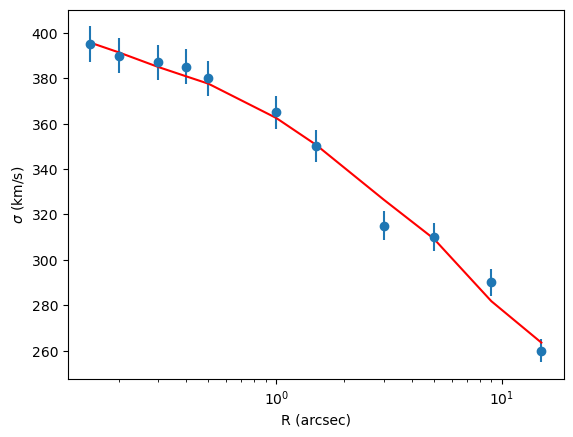

In [31]:

# Realistic MGE galaxy surface brightness.
# The surface brightness is in L_sun/pc^2 and the sigma in arcsec
#
surf_pc = np.array([6229., 3089., 5406., 8443., 4283., 1927., 708.8, 268.1, 96.83])
sigma_arcsec = np.array([0.0374, 0.286, 0.969, 2.30, 4.95, 8.96, 17.3, 36.9, 128.])

# Realistic observed stellar kinematics. It comes from AO observations
# at R < 2" and seeing-limited long slit observations at larger radii.
# The galaxy has negligible rotation, and we can use sigma as V_RMS
#
sig = np.array([395., 390., 387., 385., 380., 365., 350., 315., 310., 290., 260.])  # km/s
dsig = sig*0.02  # assume 2% errors in sigma
rad = np.array([0.15, 0.2, 0.3, 0.4, 0.5, 1, 1.5, 3, 5, 9, 15])  # arcsec

# Assume the anisotropy variation is described by the function
# beta(r) = beta_0 + (beta_inf - beta_0)/[1 + (r_a/r)^alpha]
r_a = 1         # Anisotropy transition radius in arcsec
beta_0 = -0.1   # Inner anisotropy
beta_inf = 0.5  # Outer anisotropy
alpha = 1       # Sharpness of the anisotropy transition
beta = [r_a, beta_0, beta_inf, alpha]

# Compute V_RMS profiles and optimize M/L to best fit the data.
# Assume self-consistency: same MGE for luminosity and potential.
#
pixSize = 0.1           # Spaxel size in arcsec
sigmapsf = [0.1, 0.6]   # sigma of the PSF in arcsec from AO observations
normpsf = [0.7, 0.3]
mbh = 2e8               # Black hole mass in solar masses before multiplication by M/L
distance = 20.          # Mpc

out = jam.sph.proj(surf_pc, sigma_arcsec, surf_pc, sigma_arcsec, mbh,
                   distance, rad, beta=beta, sigmapsf=sigmapsf,
                   normpsf=normpsf, pixsize=pixSize, data=sig, errors=dsig,
                   plot=True, tensor='los', logistic=True)
rms = out.model

In [ ]:
#!/usr/bin/env python3
"""
    This example illustrates how to fit a galaxy model with dark matter halo
    using the JAM package in combination with the AdaMet Bayesian package.

    V1.0.0: Michele Cappellari, Oxford, 3 October 2022

"""
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# All packages below are available at https://pypi.org/user/micappe/

from plotbin.plot_velfield import plot_velfield
from plotbin.symmetrize_velfield import symmetrize_velfield

import jampy as jam

from adamet.adamet import adamet
from adamet.corner_plot import corner_plot

from mgefit.mge_fit_1d import mge_fit_1d

###############################################################################

def summary_plot(xbin, ybin, goodbins, rms, pars, lnprob, labels, bounds, kwargs):
    """
    Print the best fitting solution with uncertainties.
    Plot the final corner plot with the best fitting JAM model.

    """
    bestfit = pars[np.argmax(lnprob)]  # Best fitting parameters
    perc = np.percentile(pars, [15.86, 84.14], axis=0)  # 68% interval
    sig_bestfit = np.squeeze(np.diff(perc, axis=0)/2)   # half of interval (1sigma)

    print("\nBest-fitting parameters and 1sigma errors:")
    for label, best, sig in zip(labels, bestfit, sig_bestfit):
        print(f"   {label} = {best:#.4g} +/- {sig:#.2g}")

    # Produce final corner plot without trial values and with best fitting JAM
    plt.clf()
    corner_plot(pars, lnprob, labels=labels, extents=bounds, fignum=1)
    chi2 = jam_lnprob(bestfit, **kwargs)  # Compute model at best fit location

    dx = 0.24
    yfac = 0.87
    fig = plt.gcf()

    fig.add_axes([0.69, 0.99 - dx*yfac, dx, dx*yfac])  # left, bottom, xsize, ysize
    rms1 = rms.copy()
    rms1[goodbins] = symmetrize_velfield(xbin[goodbins], ybin[goodbins], rms[goodbins])
    vmin, vmax = np.percentile(rms1[goodbins], [0.5, 99.5])
    plot_velfield(xbin, ybin, rms1, vmin=vmin, vmax=vmax, cmap='viridis', linescolor='w',
                  colorbar=1, label=r"Data $V_{\rm rms}$ (km/s)", flux=jam_lnprob.flux_model)
    plt.tick_params(labelbottom=False)
    plt.ylabel('arcsec')

    fig.add_axes([0.69, 0.98 - 2*dx*yfac, dx, dx*yfac])  # left, bottom, xsize, ysize
    plot_velfield(xbin, ybin, jam_lnprob.rms_model, vmin=vmin, vmax=vmax, cmap='viridis', linescolor='w',
                  colorbar=1, label=r"Model $V_{\rm rms}$ (km/s)", flux=jam_lnprob.flux_model)
    plt.tick_params(labelbottom=False)
    plt.ylabel('arcsec')

###############################################################################

def dark_halo_mge(gamma, rbreak):
    """
    Returns the MGE parameters for a generalized NFW dark halo profile
    https://ui.adsabs.harvard.edu/abs/2001ApJ...555..504W
    - gamma is the inner logarithmic slope (gamma = -1 for NFW)
    - rbreak is the break radius in arcsec

    """
    # The fit is performed in log spaced radii from 1" to 10*rbreak
    n = 300     # Number of values to sample the gNFW profile for the MGE fit
    r = np.geomspace(1, rbreak*10, n)   # logarithmically spaced radii in arcsec
    rho = (r/rbreak)**gamma * (0.5 + 0.5*r/rbreak)**(-gamma - 3)  # rho=1 at r=rbreak
    m = mge_fit_1d(r, rho, ngauss=15, quiet=1, plot=0)

    surf_dm, sigma_dm = m.sol           # Peak surface density and sigma
    qobs_dm = np.ones_like(surf_dm)     # Assume spherical dark halo

    return surf_dm, sigma_dm, qobs_dm

###############################################################################

def total_mass_mge(surf_lum, sigma_lum, qobs_lum, gamma, rbreak, f_dm, inc):
    """
    Combine the MGE from a dark halo and the MGE from the stellar surface
    brightness in such a way to have a given dark matter fractions f_dm
    inside a sphere of radius one half-light radius reff

    """
    surf_dm, sigma_dm, qobs_dm = dark_halo_mge(gamma, rbreak)

    reff = jam.mge.half_light_radius(surf_lum, sigma_lum, qobs_lum)[0]
    stars_lum_re = jam.mge.radial_mass(surf_lum, sigma_lum, qobs_lum, inc, reff)
    dark_mass_re = jam.mge.radial_mass(surf_dm, sigma_dm, qobs_dm, inc, reff)

    # Find the scale factor needed to satisfy the following definition
    # f_dm == dark_mass_re*scale/(stars_lum_re + dark_mass_re*scale)
    scale = (f_dm*stars_lum_re)/(dark_mass_re*(1 - f_dm))

    surf_pot = np.append(surf_lum, surf_dm*scale)   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    sigma_pot = np.append(sigma_lum, sigma_dm)      # Gaussian dispersion in arcsec
    qobs_pot = np.append(qobs_lum, qobs_dm)

    return surf_pot, sigma_pot, qobs_pot

###############################################################################

def jam_lnprob(pars, surf_lum=None, sigma_lum=None, qobs_lum=None, distance=None,
              xbin=None, ybin=None, sigmapsf=None, normpsf=None, goodbins=None,
              rms=None, erms=None, pixsize=None, plot=True):
    """
    Return the probability of the model, given the data, assuming constant priors

    """
    q, ratio, f_dm, lg_ml = pars

    # Sample inclination using min(q), with Equation (14) of Cappellari (2008)
    qmin = np.min(qobs_lum)
    inc = np.degrees(np.arctan2(np.sqrt(1 - qmin**2), np.sqrt(qmin**2 - q**2)))
    beta = np.full_like(qobs_lum, 1 - ratio**2)   # assume constant anisotropy

    # In this example I keep the halo slope and break radius fixed.
    # These parameters could be fitted from good and spatially-extended data.
    gamma = -1                  # Adopt fixed NFW inner halos slope
    rbreak = 20e3               # Adopt fixed halo break radius of 20 kpc (much larger than the data)
    pc = distance*np.pi/0.648   # Constant factor to convert arcsec --> pc
    rbreak /= pc                # Convert the break radius from pc --> arcsec
    mbh = 0                     # Ignore the central black hole
    surf_pot, sigma_pot, qobs_pot = total_mass_mge(surf_lum, sigma_lum, qobs_lum, gamma, rbreak, f_dm, inc)

    # Note: I multiply surf_pot by ml=10**lg_ml, while I set the keyword ml=1
    # Both the stellar and dark matter increase by ml and f_dm is unchanged
    surf_pot *= 10**lg_ml
    out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                       inc, mbh, distance, xbin, ybin, plot=plot, pixsize=pixsize, quiet=1,
                       sigmapsf=sigmapsf, normpsf=normpsf, goodbins=goodbins, align='cyl',
                       beta=beta, data=rms, errors=erms, ml=1)

    # These two lines are just used for the final plot
    jam_lnprob.rms_model = out.model
    jam_lnprob.flux_model = out.flux

    resid = (rms[goodbins] - out.model[goodbins])/erms[goodbins]
    chi2 = resid @ resid

    return -0.5*chi2   # ln(likelihood) + cost.

##############################################################################



Started AdaMet please wait...
This example takes about 15 min on a 2GHz CPU
Progress is printed roughly every minute


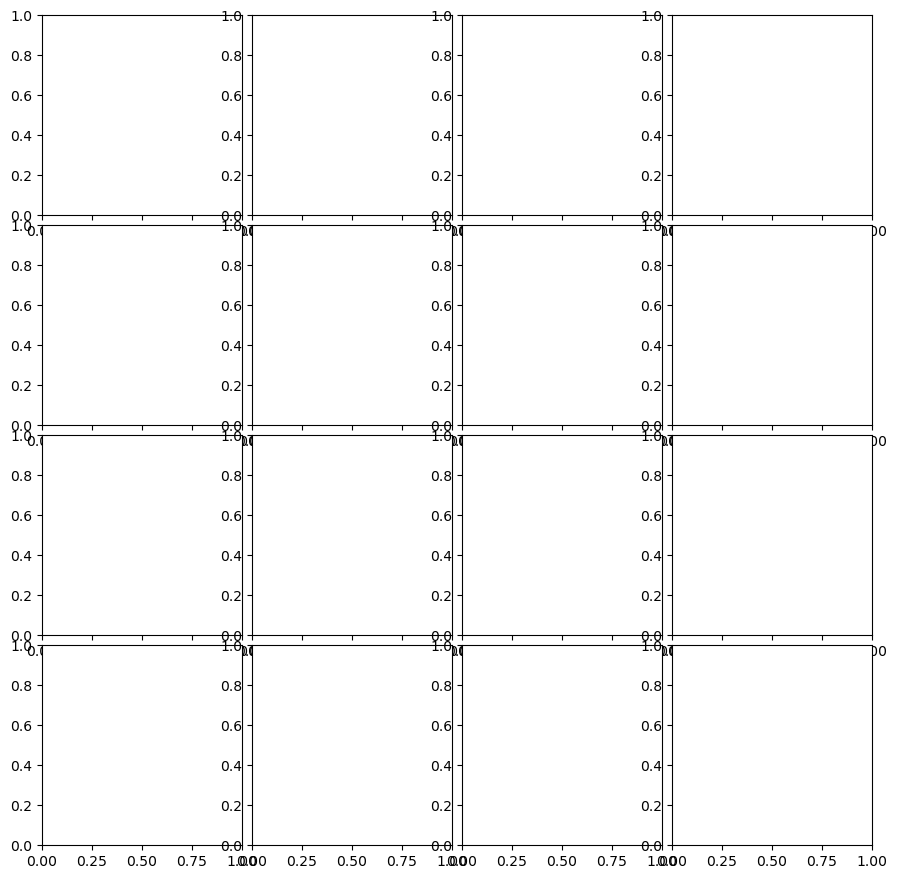

adamet: 10.0 % done; 4.0 % accepted
adamet: 20.0 % done; 4.5 % accepted
adamet: 30.0 % done; 17.0 % accepted
adamet: 40.0 % done; 24.8 % accepted
adamet: 50.0 % done; 27.6 % accepted
adamet: 60.0 % done; 29.5 % accepted
adamet: 70.0 % done; 30.6 % accepted
adamet: 80.0 % done; 31.5 % accepted
adamet: 90.0 % done; 31.6 % accepted
adamet: 100.0 % done; 30.6 % accepted
adamet: done. Total time 190.49 seconds

Best-fitting parameters and 1sigma errors:
   $q_{\rm min}$ = 0.5094 +/- 0.16
   $\sigma_z/\sigma_R$ = 0.8510 +/- 0.052
   $f_{\rm DM}$ = 0.2128 +/- 0.049
   $\lg(M_\ast/L)$ = 0.1456 +/- 0.038


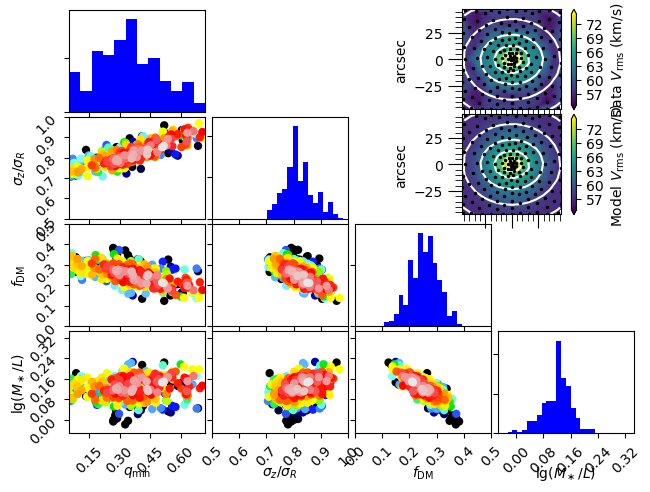

In [35]:
# MGE model of the galaxy M32 from Table B1 of Cappellari et al. (2006)
# http://adsabs.harvard.edu/abs/2006MNRAS.366.1126C
surf_lum = 10**np.array([6.187, 5.774, 5.766, 5.613, 5.311, 4.774, 4.359, 4.087, 3.682, 3.316, 2.744, 1.618])
sigma_lum = 10**np.array([-1.762, -1.143, -0.839, -0.438, -0.104, 0.232, 0.560, 0.835, 1.160, 1.414, 1.703, 2.249])
qobs_lum = np.array([0.790, 0.741, 0.786, 0.757, 0.720, 0.724, 0.725, 0.743, 0.751, 0.838, 0.835, 0.720])

# Read mock kinematics with realistic parameters and noise
jam_dir = Path(jam.__file__).parent
filename = jam_dir / 'examples' / 'jam_mock_kinematics_dark_halo.txt'
xbin, ybin, rms, erms, flux = np.loadtxt(filename).T
distance = 0.7   # M32 Distance

# The following line tries to *approximately* account for systematic errors.
# See beginning of Sec.6.1 of Mitzkus+17 for an explanation
# https://ui.adsabs.harvard.edu/abs/2017MNRAS.464.4789M
erms *= (2*rms.size)**0.25

# Starting guess, e.g. from a previous least-squares fit
q0 = 0.55               # Axial ratio of the flattest MGE Gaussian
ratio0 = 0.9            # Anisotropy ratio sigma_z/sigma_R
f_dm0 = 0.15            # Dark matter fraction inside a sphere of radius Re
lg_ml0 = np.log10(1.4)  # I sample the M/L logarithmically

pixsize = 2             # spaxel size in arcsec (before Voronoi binning)
sigmapsf = 4/2.355      # sigma PSF in arcsec (=FWHM/2.355)
normpsf = 1

# I adjusted the fitting range below after an initial fit which
# gave me an idea of some suitable ranges for the parameters
qmin = np.min(qobs_lum)
p0 = [q0, ratio0, f_dm0, lg_ml0]
bounds = [[0.051, 0.5, 0, lg_ml0-0.2], [qmin, 1, 0.5, lg_ml0+0.2]]
labels = [r"$q_{\rm min}$", r"$\sigma_z/\sigma_R$", r"$f_{\rm DM}$", r"$\lg(M_\ast/L)$"]

goodbins = np.isfinite(xbin)  # Here I fit all bins

# These parameters are passed to JAM
kwargs = {'surf_lum': surf_lum, 'sigma_lum': sigma_lum, 'qobs_lum': qobs_lum,
          'distance': distance, 'xbin': xbin, 'ybin': ybin, 'sigmapsf': sigmapsf,
          'normpsf': normpsf, 'rms': rms, 'erms': erms, 'pixsize': pixsize,
          'goodbins': goodbins, 'plot': 0}

# This is a rather small number of steps for illustration.
# But the distribution has already qualitatively converged
nstep = 1000
sigpar = np.array([0.15, 0.15, 0.05, 0.05])  # crude estimate of uncertainties

# The acceptance rate approaches the optimal theoretical value of 28% in 4-dim
print("Started AdaMet please wait...")
print("This example takes about 15 min on a 2GHz CPU")
print("Progress is printed roughly every minute")
pars, lnprob = adamet(jam_lnprob, p0, sigpar, bounds, nstep, fignum=1,
                      kwargs=kwargs, nprint=nstep/10, labels=labels, seed=2)

summary_plot(xbin, ybin, goodbins, rms, pars, lnprob, labels, bounds, kwargs)

In [36]:
pars

array([[0.55      , 0.9       , 0.15      , 0.14612804],
       [0.55      , 0.9       , 0.15      , 0.14612804],
       [0.55      , 0.9       , 0.15      , 0.14612804],
       ...,
       [0.06556714, 0.7622413 , 0.35744143, 0.08128061],
       [0.06556714, 0.7622413 , 0.35744143, 0.08128061],
       [0.06556714, 0.7622413 , 0.35744143, 0.08128061]])